In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import seaborn as sns

In [14]:
adata_tfa_vis=sc.read_h5ad("out/stf_results_tfa_only.h5ad")
adata_tfa=sc.read_h5ad("out/sc_tfa_only.h5ad")

In [15]:
sc.pp.scale(adata_tfa)
sc.pp.scale(adata_tfa_vis)

sc_df=adata_tfa.to_df()
st_df=adata_tfa_vis.to_df()

tf_names=np.intersect1d(sc_df.columns, st_df.columns)
sc_df=sc_df[tf_names]
st_df=st_df[tf_names]

In [16]:
sc_score=sc_df.groupby(adata_tfa.obs['Subset']).mean().T

In [17]:
vis_score=np.linalg.pinv(adata_tfa_vis.obsm['celltype']).dot(st_df).T
vis_score=pd.DataFrame(vis_score, columns=adata_tfa_vis.obsm['celltype'].columns, index=st_df.columns)

In [8]:
# ct_subset=[ct for (x, ct) in zip(adata_tfa_vis.obsm['celltype'].quantile(0.99), adata_tfa_vis.obsm['celltype'].columns) if x>0.07]
# vis_score=vis_score[ct_subset]
# sc_score=sc_score[ct_subset]

In [18]:
sc_score=(sc_score-sc_score.mean())/sc_score.std()
vis_score=(vis_score-vis_score.mean())/vis_score.std()

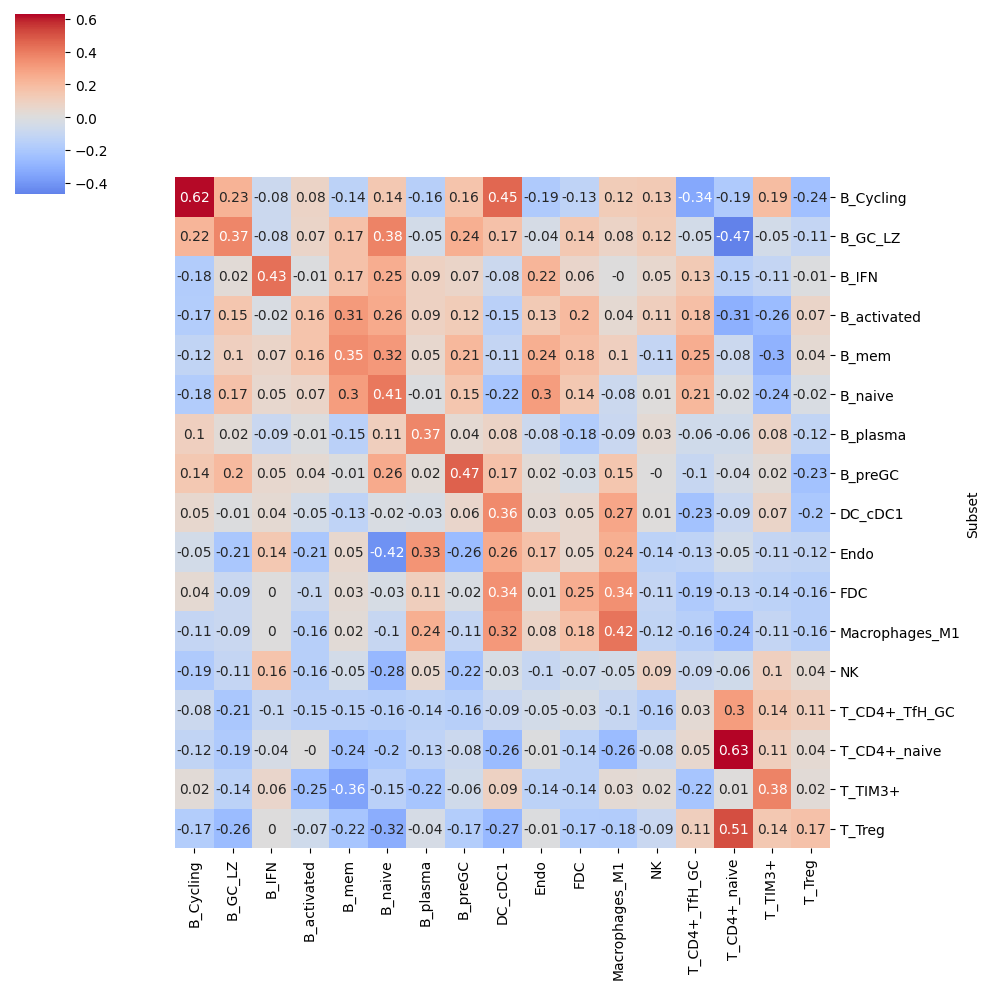

In [10]:
from scipy.cluster.hierarchy import linkage

link_mat=linkage(sc_score.T, metric='correlation')

sns.clustermap((sc_score.T.dot(vis_score)/176).round(2),col_cluster=False, row_cluster=False, annot=True, cmap="coolwarm", center=0)

In [11]:
tfs=ct_tf_df.query("(ct=='B_GC_DZ' or ct=='B_GC_LZ') and p_adj <0.001").sort_values('coef', ascending=False).head(12)['tf'].to_list()
plt.figure(figsize=(5,7))
i=0
ticks=[]
labels=[]
for tf in tfs:


    ticks.append(i+0.5)
    labels.append(tf)

    coef=ct_tf_df.query("ct=='B_GC_DZ' and tf==@tf")['coef']
    se=ct_tf_df.query("ct=='B_GC_DZ' and tf==@tf")['SE']
    plt.errorbar(coef, i, yerr=None, xerr=2*se, color='r')
    plt.plot(coef,i, 'o', color='r')
    i=i+1
    coef=ct_tf_df.query("ct=='B_GC_LZ' and tf==@tf")['coef']
    se=ct_tf_df.query("ct=='B_GC_LZ' and tf==@tf")['SE']
    plt.errorbar(coef, i, yerr=None, xerr=2*se, color='b')
    plt.plot(coef,i, 'o', color='b')
    # ticks.append(i)
    # labels.append(tf+" LZ")

    i=i+1
    plt.hlines(i, -20,20, color='black')
    i=i+1

plt.yticks(ticks, labels)
plt.xlim(-7,15)
plt.vlines(0,-1,  i+3, colors=None, linestyles='dashed')
plt.ylim(-1,i-1)
plt.xlabel("Cell Type Score")

plt.plot([-10,-10], [-11,-11], 'o-',label='B_GC_DZ', color='r')
plt.plot([-10,-10], [-11,-11], 'o-',label='B_LC_DZ', color='b')
plt.legend(bbox_to_anchor=(1.05,1),
           loc='upper left',
           borderaxespad=0)


NameError: name 'ct_tf_df' is not defined

In [19]:
sc_score[['B_GC_LZ', 'B_GC_DZ']]


Subset,B_GC_LZ,B_GC_DZ
AHR,0.508922,0.567059
AR,0.091589,-0.328063
ARID3A,-1.343683,-1.338783
ARNT,0.634984,1.164253
ARNTL,-0.654114,-1.243575
...,...,...
ZNF250,0.009128,-0.557713
ZNF263,0.911655,0.682961
ZNF281,0.777308,0.697000
ZNF384,0.392033,1.495434


In [20]:
vis_score[['B_GC_LZ', 'B_GC_DZ']]

,B_GC_LZ,B_GC_DZ
AHR,-0.335271,0.749483
AR,0.416711,1.860284
ARID3A,0.023840,-0.439232
ARNT,1.226820,-0.463309
ARNTL,-1.090099,-0.537965
...,...,...
ZNF250,-0.000530,2.465950
ZNF263,0.114136,0.652055
ZNF281,-1.057353,-0.166401
ZNF384,-0.331378,-0.383107


['B_Cycling',
 'B_GC_LZ',
 'B_IFN',
 'B_activated',
 'B_mem',
 'B_naive',
 'B_plasma',
 'B_preGC',
 'DC_cDC1',
 'Endo',
 'FDC',
 'Macrophages_M1',
 'NK',
 'T_CD4+_TfH_GC',
 'T_CD4+_naive',
 'T_TIM3+',
 'T_Treg']